In [14]:
import json

import polars as pl
from project_paths import paths

experiment_dir = paths.experiments / "final_grid"

results_file = experiment_dir / "runs.jsonl"

# with open(results_file) as f:
#     lines = [line for line in f]
#     results = json.loads(lines[-1])

# exclude the frank hall run
with open(results_file) as f:
    runs = [json.loads(line) for line in f]
    results = next(r for r in reversed(runs) if r["pass"] == "grid")


results 

{'run_id': 'f6b84f42-9ea3-4620-b55c-5a8c28eb1ebb',
 'run_at': '2026-08-12 17:24:12',
 'name': 'final_grid',
 'pass': 'grid',
 'git_sha': 'c8de580d6abcf2823aa96f2cdb1c18f75012fcdb',
 'seed': 123,
 'n_blocks': 50,
 'n_workers': 20,
 'omp_num_threads': 1,
 'n_cells_total': 2883,
 'n_cells_run': 2835,
 'n_cells_skipped': 48,
 'protection_type_null_count': 285,
 'oof_proba_dtype': 'float32',
 'smoke': False,
 'n_splits': 10,
 'n_assets': 23304,
 'n_configs': 1440,
 'grid': {'capacity': [1.6, 2.5, 4.0, 5.0, 6.0],
  'learning_rate': [0.00625, 0.0125, 0.025, 0.05],
  'max_leaf_nodes': [4, 8, 16, 31],
  'min_samples_leaf': [5, 10, 20],
  'max_bins': [16, 32, 255],
  'l2_regularization': [0.0, 1.0]},
 'fixed_params': {'max_depth': None,
  'max_features': 1.0,
  'early_stopping': False,
  'class_weight': None,
  'random_state': 123},
 'reference_config': {'capacity': 2.5,
  'learning_rate': 0.025,
  'max_leaf_nodes': 8,
  'min_samples_leaf': 20,
  'max_bins': 255,
  'l2_regularization': 0.0},
 'm

In [15]:

folds = pl.read_parquet(experiment_dir/"folds.parquet")
folds

asset_id,block_id,fold_id
i64,i16,i8
100006,20,3
100010,20,3
100015,14,3
100016,14,3
100017,14,3
…,…,…
99960,44,9
99963,36,1
99966,31,6


In [16]:
from typing import Iterable

oof_dir = experiment_dir / "oof"
oof_files = oof_dir.glob("*.parquet")

# loads in memory, switching to lazy evaluation and generator

frames: Iterable[pl.DataFrame] = (pl.read_parquet(file) for file in oof_files)

# frames[0]

In [17]:
# this takes about 25 mins with the extra frames

import numpy as np

from src.cross_validate import GRADES, Predictions
from src.metrics import build_scorers


fold_metrics_path = experiment_dir / "fold_metrics.parquet"
if fold_metrics_path.exists():
    fold_metrics = pl.read_parquet(fold_metrics_path)
else:
    

    proba_cols = [f"proba_{grade}" for grade in GRADES]
    scorers = build_scorers()

    # print(len(frames))

    fold_stats = []

    for frame in frames:
        # print(len(frame))
        for fold, data in frame.group_by("fold_id"):
            # print(fold)
            # print(data)

            fold_id = fold[0]
            y_values = data.get_column("y_true").to_numpy()

            prediction = Predictions(
                label=data.get_column("y_pred_argmax").to_numpy(),
                proba=data.select(proba_cols).to_numpy(),
                classes=np.asarray(GRADES),
            ) 

            fold_results = {
                "cell_id": data.get_column("cell_id").unique().item(),
                "fold_id": int(fold_id),
                "n": data.height,
                "n_ge4": int((y_values >= 4).sum()),
                **{name: float(fn(y_values, prediction)) for name, fn in scorers.items()},
            }

            fold_stats.append(fold_results)

    # fold_stats


    fold_metrics = pl.DataFrame(fold_stats).sort("cell_id", "fold_id")

    fold_metrics.write_parquet(fold_metrics_path)

fold_metrics.head()


cell_id,fold_id,n,n_ge4,mae,macro_f1,qwk,pr_auc_ge4,recall_for_grade_1,recall_for_grade_2,recall_for_grade_3,recall_for_grade_4,recall_for_grade_5,precision_for_grade_1,precision_for_grade_2,precision_for_grade_3,precision_for_grade_4,precision_for_grade_5,f1_for_grade_1,f1_for_grade_2,f1_for_grade_3,f1_for_grade_4,f1_for_grade_5
str,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""000ed8575bc5""",0,2174,263,0.377645,0.325078,0.33791,0.198025,0.315789,0.331046,0.917054,0.0,0.0,0.75,0.57958,0.648219,0.0,0.0,0.444444,0.421397,0.759551,0.0,0.0
"""000ed8575bc5""",1,2201,188,0.408451,0.235046,0.255563,0.187446,0.042553,0.274425,0.912598,0.0,0.0,0.125,0.545714,0.631608,0.0,0.0,0.063492,0.365201,0.746538,0.0,0.0
"""000ed8575bc5""",2,2486,215,0.300885,0.265831,0.345993,0.294831,0.046512,0.330357,0.946643,0.0,0.0,0.285714,0.602606,0.72698,0.0,0.0,0.08,0.426759,0.822396,0.0,0.0
"""000ed8575bc5""",3,2601,216,0.334487,0.290318,0.302327,0.122985,0.177778,0.296898,0.942874,0.0,0.0,0.421053,0.622291,0.694112,0.0,0.0,0.25,0.402,0.799592,0.0,0.0
"""000ed8575bc5""",4,2294,182,0.364429,0.280967,0.301534,0.138415,0.214286,0.209375,0.951271,0.0,0.0,0.631579,0.55144,0.662894,0.0,0.0,0.32,0.303511,0.781323,0.0,0.0


In [18]:
id_cols = ["cell_id", "fold_id", "n", "n_ge4"]
long = fold_metrics.unpivot(
    index=id_cols,
    on=[c for c in fold_metrics.columns if c not in id_cols],
    variable_name="metric",
    value_name="value",
)

long.head()

cell_id,fold_id,n,n_ge4,metric,value
str,i64,i64,i64,str,f64
"""000ed8575bc5""",0,2174,263,"""mae""",0.377645
"""000ed8575bc5""",1,2201,188,"""mae""",0.408451
"""000ed8575bc5""",2,2486,215,"""mae""",0.300885
"""000ed8575bc5""",3,2601,216,"""mae""",0.334487
"""000ed8575bc5""",4,2294,182,"""mae""",0.364429


In [19]:
import json

meta_dir = experiment_dir / "meta"

GRID_AXES = [
    "learning_rate",
    "max_iter",
    "max_leaf_nodes",
    "max_depth",
    "max_bins",
    "l2_regularization",
    "min_samples_leaf",
]

records = [json.loads(p.read_text()) for p in sorted(meta_dir.glob("*.json"))]

records = [r for r in records if r["model"] != "frank_hall"]

cell_meta = pl.DataFrame(
    [
        {
            "cell_id": r["cell_id"],
            "model": r["model"],
            "composition": r["composition"],
            "capacity": r.get("capacity"),
            "seconds_fit": r.get("seconds_fit"),
            "seconds_shap": r.get("seconds_shap"),
            "seconds_total": r.get("seconds_total"),
            **{axis: r["params"].get(axis) for axis in GRID_AXES},
        }
        for r in records
    ],
    infer_schema_length=None,
).with_columns(
    pl.when(pl.col("composition").is_null())
    .then(None)
    .otherwise(
        pl.concat_str(
            [pl.col(a).cast(pl.Utf8).fill_null("none") for a in GRID_AXES],
            separator="|",
        )
    )
    .alias("config_key")
)

assert cell_meta.height == results["n_cells_total"], (
    f"{cell_meta.height} meta files vs {results['n_cells_total']} expected"
)
assert cell_meta.filter(pl.col("model") == "hgb").get_column("config_key").null_count() == 0
# assert cell_meta.filter(pl.col("model") == "hgb").get_column("config_key").n_unique() == 630

fold_metrics = fold_metrics.join(cell_meta, on="cell_id", how="left", validate="m:1")
fold_metrics.head()

cell_id,fold_id,n,n_ge4,mae,macro_f1,qwk,pr_auc_ge4,recall_for_grade_1,recall_for_grade_2,recall_for_grade_3,recall_for_grade_4,recall_for_grade_5,precision_for_grade_1,precision_for_grade_2,precision_for_grade_3,precision_for_grade_4,precision_for_grade_5,f1_for_grade_1,f1_for_grade_2,f1_for_grade_3,f1_for_grade_4,f1_for_grade_5,model,composition,capacity,seconds_fit,seconds_shap,seconds_total,learning_rate,max_iter,max_leaf_nodes,max_depth,max_bins,l2_regularization,min_samples_leaf,config_key
str,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,i64,i64,null,i64,f64,i64,str
"""000ed8575bc5""",0,2174,263,0.377645,0.325078,0.33791,0.198025,0.315789,0.331046,0.917054,0.0,0.0,0.75,0.57958,0.648219,0.0,0.0,0.444444,0.421397,0.759551,0.0,0.0,"""hgb""","""identity_lidar_climate_raw""",5.0,50.218,0.0,56.959,0.0125,400,4,null,255,1.0,20,"""0.0125|400|4|none|255|1.0|20"""
"""000ed8575bc5""",1,2201,188,0.408451,0.235046,0.255563,0.187446,0.042553,0.274425,0.912598,0.0,0.0,0.125,0.545714,0.631608,0.0,0.0,0.063492,0.365201,0.746538,0.0,0.0,"""hgb""","""identity_lidar_climate_raw""",5.0,50.218,0.0,56.959,0.0125,400,4,null,255,1.0,20,"""0.0125|400|4|none|255|1.0|20"""
"""000ed8575bc5""",2,2486,215,0.300885,0.265831,0.345993,0.294831,0.046512,0.330357,0.946643,0.0,0.0,0.285714,0.602606,0.72698,0.0,0.0,0.08,0.426759,0.822396,0.0,0.0,"""hgb""","""identity_lidar_climate_raw""",5.0,50.218,0.0,56.959,0.0125,400,4,null,255,1.0,20,"""0.0125|400|4|none|255|1.0|20"""
"""000ed8575bc5""",3,2601,216,0.334487,0.290318,0.302327,0.122985,0.177778,0.296898,0.942874,0.0,0.0,0.421053,0.622291,0.694112,0.0,0.0,0.25,0.402,0.799592,0.0,0.0,"""hgb""","""identity_lidar_climate_raw""",5.0,50.218,0.0,56.959,0.0125,400,4,null,255,1.0,20,"""0.0125|400|4|none|255|1.0|20"""
"""000ed8575bc5""",4,2294,182,0.364429,0.280967,0.301534,0.138415,0.214286,0.209375,0.951271,0.0,0.0,0.631579,0.55144,0.662894,0.0,0.0,0.32,0.303511,0.781323,0.0,0.0,"""hgb""","""identity_lidar_climate_raw""",5.0,50.218,0.0,56.959,0.0125,400,4,null,255,1.0,20,"""0.0125|400|4|none|255|1.0|20"""


In [20]:
cell_metrics_cv =  (
    long.group_by("cell_id", "metric")
    .agg(
        pl.col("value").filter(pl.col("value").is_not_nan()).mean().alias("mean"),
        pl.col("value").filter(pl.col("value").is_not_nan()).std().alias("std"),
        pl.col("value").is_nan().sum().alias("n_nan"),
        pl.len().alias("n_folds"),
    )
    .join(cell_meta, on="cell_id", how="left", validate="m:1")
    .sort("metric", "mean", descending=[False, True])
)

cell_metrics_cv.head()

cell_id,metric,mean,std,n_nan,n_folds,model,composition,capacity,seconds_fit,seconds_shap,seconds_total,learning_rate,max_iter,max_leaf_nodes,max_depth,max_bins,l2_regularization,min_samples_leaf,config_key
str,str,f64,f64,u32,u32,str,str,f64,f64,f64,f64,f64,i64,i64,null,i64,f64,i64,str
"""605a83948685""","""f1_for_grade_1""",0.259828,0.252417,0,10,"""hgb""","""identity_lidar_full""",6.0,16.875,0.0,19.156,0.05,120,8,null,255,0.0,10,"""0.05|120|8|none|255|0.0|10"""
"""f0cd7fb6d9de""","""f1_for_grade_1""",0.259534,0.253033,0,10,"""hgb""","""identity_lidar_full""",5.0,14.98,0.0,17.156,0.05,100,8,null,255,0.0,10,"""0.05|100|8|none|255|0.0|10"""
"""a69ed93b9483""","""f1_for_grade_1""",0.256002,0.248265,0,10,"""hgb""","""identity_lidar_full""",5.0,31.064,0.0,35.524,0.025,200,8,null,255,0.0,5,"""0.025|200|8|none|255|0.0|5"""
"""857246d8f022""","""f1_for_grade_1""",0.253373,0.25416,0,10,"""hgb""","""identity_lidar_full""",6.0,18.217,0.0,20.923,0.05,120,8,null,255,1.0,20,"""0.05|120|8|none|255|1.0|20"""
"""1e71b56c0d2c""","""f1_for_grade_1""",0.251612,0.254967,0,10,"""hgb""","""identity_lidar_full""",4.0,12.934,0.0,14.764,0.05,80,8,null,255,0.0,10,"""0.05|80|8|none|255|0.0|10"""


In [21]:
cell_summary = (
    cell_metrics_cv.pivot(on="metric", index="cell_id", values="mean")
    .join(cell_meta, on="cell_id", how="left", validate="1:1")
    .sort("composition", "pr_auc_ge4", descending=[False, True])
)

cell_summary

cell_id,f1_for_grade_1,f1_for_grade_2,f1_for_grade_3,f1_for_grade_4,f1_for_grade_5,macro_f1,mae,pr_auc_ge4,precision_for_grade_1,precision_for_grade_2,precision_for_grade_3,precision_for_grade_4,precision_for_grade_5,qwk,recall_for_grade_1,recall_for_grade_2,recall_for_grade_3,recall_for_grade_4,recall_for_grade_5,model,composition,capacity,seconds_fit,seconds_shap,seconds_total,learning_rate,max_iter,max_leaf_nodes,max_depth,max_bins,l2_regularization,min_samples_leaf,config_key
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,i64,i64,null,i64,f64,i64,str
"""ba81faf7a77c""",0.154872,0.259339,0.605702,0.058673,0.025921,0.220901,0.794041,0.098838,0.092383,0.369976,0.653088,0.066111,0.015269,0.185143,0.537633,0.208785,0.576927,0.066264,0.124264,"""heuristic_national""",null,null,0.0,0.0,0.105,null,null,null,null,null,null,null,null
"""0c7581b6dc44""",0.013038,0.274346,0.612037,0.086004,0.0,0.197085,0.641249,0.097513,0.014421,0.275233,0.609304,0.089209,0.0,-0.000851,0.012114,0.275723,0.616531,0.084127,0.0,"""dummy_stratified""",null,null,0.018,0.0,0.171,null,null,null,null,null,null,null,null
"""4afa0082a12f""",0.0,0.0,0.756443,0.0,0.0,0.151289,0.421228,0.096583,0.0,0.0,0.609269,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,"""dummy_median""",null,null,0.014,0.0,0.13,null,null,null,null,null,null,null,null
"""8de98379fe6f""",0.118617,0.383832,0.76868,0.00099,0.0,0.254424,0.377966,0.197655,0.261515,0.559102,0.660649,0.1,0.0,0.280176,0.087056,0.295257,0.921041,0.000498,0.0,"""hgb""","""identity_lidar_climate_raw""",1.6,22.54,0.0,24.584,0.025,64,31,null,255,0.0,5,"""0.025|64|31|none|255|0.0|5"""
"""ac8e0ca29f7d""",0.164488,0.389166,0.766735,0.00099,0.0,0.264276,0.37978,0.197114,0.312538,0.549168,0.661617,0.1,0.0,0.282732,0.118255,0.304361,0.913604,0.000498,0.0,"""hgb""","""identity_lidar_climate_raw""",2.5,122.418,0.0,134.612,0.00625,400,31,null,255,0.0,5,"""0.00625|400|31|none|255|0.0|5"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""a377d852729b""",0.152169,0.394272,0.757161,0.018632,0.004762,0.265399,0.394685,0.180695,0.300476,0.525122,0.661053,0.224496,0.014286,0.272025,0.112851,0.320802,0.887944,0.010718,0.002857,"""hgb""","""identity_lidar_full""",6.0,25.52,0.0,28.886,0.05,120,31,null,16,0.0,10,"""0.05|120|31|none|16|0.0|10"""
"""23d681edd631""",0.027397,0.36785,0.770507,0.0,0.0,0.233151,0.375225,0.180632,0.058824,0.567237,0.657108,0.0,0.0,0.263898,0.017857,0.277356,0.933929,0.0,0.0,"""hgb""","""identity_lidar_full""",1.6,5.963,0.0,7.016,0.05,32,4,null,16,1.0,10,"""0.05|32|4|none|16|1.0|10"""
"""b6774a9ecec6""",0.027397,0.36785,0.770507,0.0,0.0,0.233151,0.375225,0.180632,0.058824,0.567237,0.657108,0.0,0.0,0.263898,0.017857,0.277356,0.933929,0.0,0.0,"""hgb""","""identity_lidar_full""",1.6,6.121,0.0,7.272,0.05,32,4,null,16,1.0,5,"""0.05|32|4|none|16|1.0|5"""


In [22]:

with pl.Config(tbl_rows=-1):
    print(
        cell_metrics_cv.filter(pl.col("metric") == "pr_auc_ge4").group_by("composition", "model").agg(
            pl.col("mean").max().alias("best"),
            pl.col("mean").median().alias("median"),
            pl.col("mean").min().alias("worst"),
        )
    )

shape: (5, 5)
┌────────────────────────────┬────────────────────┬──────────┬──────────┬──────────┐
│ composition                ┆ model              ┆ best     ┆ median   ┆ worst    │
│ ---                        ┆ ---                ┆ ---      ┆ ---      ┆ ---      │
│ str                        ┆ str                ┆ f64      ┆ f64      ┆ f64      │
╞════════════════════════════╪════════════════════╪══════════╪══════════╪══════════╡
│ null                       ┆ dummy_stratified   ┆ 0.097513 ┆ 0.097513 ┆ 0.097513 │
│ identity_lidar_full        ┆ hgb                ┆ 0.19595  ┆ 0.189639 ┆ 0.179358 │
│ null                       ┆ heuristic_national ┆ 0.098838 ┆ 0.098838 ┆ 0.098838 │
│ identity_lidar_climate_raw ┆ hgb                ┆ 0.197655 ┆ 0.188708 ┆ 0.177078 │
│ null                       ┆ dummy_median       ┆ 0.096583 ┆ 0.096583 ┆ 0.096583 │
└────────────────────────────┴────────────────────┴──────────┴──────────┴──────────┘


In [23]:

with pl.Config(tbl_rows=-1):
    print(
        cell_metrics_cv.filter(pl.col("metric") == "qwk").group_by("composition", "model").agg(
            pl.col("mean").max().alias("best"),
            pl.col("mean").median().alias("median"),
            pl.col("mean").min().alias("worst"),
        )
    )

shape: (5, 5)
┌────────────────────────────┬────────────────────┬───────────┬───────────┬───────────┐
│ composition                ┆ model              ┆ best      ┆ median    ┆ worst     │
│ ---                        ┆ ---                ┆ ---       ┆ ---       ┆ ---       │
│ str                        ┆ str                ┆ f64       ┆ f64       ┆ f64       │
╞════════════════════════════╪════════════════════╪═══════════╪═══════════╪═══════════╡
│ identity_lidar_climate_raw ┆ hgb                ┆ 0.293851  ┆ 0.282507  ┆ 0.257243  │
│ null                       ┆ dummy_stratified   ┆ -0.000851 ┆ -0.000851 ┆ -0.000851 │
│ null                       ┆ heuristic_national ┆ 0.185143  ┆ 0.185143  ┆ 0.185143  │
│ identity_lidar_full        ┆ hgb                ┆ 0.300623  ┆ 0.288233  ┆ 0.260892  │
│ null                       ┆ dummy_median       ┆ 0.0       ┆ 0.0       ┆ 0.0       │
└────────────────────────────┴────────────────────┴───────────┴───────────┴───────────┘


In [24]:
with pl.Config(tbl_rows=-1):
    print(

        cell_metrics_cv.filter(pl.col("metric") == "macro_f1").group_by("composition", "model").agg(
            pl.col("mean").max().alias("best"),
            pl.col("mean").median().alias("median"),
            pl.col("mean").min().alias("worst"),
        )

    )

shape: (5, 5)
┌────────────────────────────┬────────────────────┬──────────┬──────────┬──────────┐
│ composition                ┆ model              ┆ best     ┆ median   ┆ worst    │
│ ---                        ┆ ---                ┆ ---      ┆ ---      ┆ ---      │
│ str                        ┆ str                ┆ f64      ┆ f64      ┆ f64      │
╞════════════════════════════╪════════════════════╪══════════╪══════════╪══════════╡
│ identity_lidar_climate_raw ┆ hgb                ┆ 0.27526  ┆ 0.263135 ┆ 0.228466 │
│ identity_lidar_full        ┆ hgb                ┆ 0.284954 ┆ 0.271452 ┆ 0.230136 │
│ null                       ┆ dummy_stratified   ┆ 0.197085 ┆ 0.197085 ┆ 0.197085 │
│ null                       ┆ heuristic_national ┆ 0.220901 ┆ 0.220901 ┆ 0.220901 │
│ null                       ┆ dummy_median       ┆ 0.151289 ┆ 0.151289 ┆ 0.151289 │
└────────────────────────────┴────────────────────┴──────────┴──────────┴──────────┘


In [25]:
shap_agg = pl.concat(
    [pl.read_parquet(path) for path in sorted((experiment_dir / "shap_agg").glob("*.parquet"))]
).join(cell_meta, on="cell_id", how="left", validate="m:1")

feature_importance = (
    shap_agg.group_by("composition", "feature", "grade")
    .agg(
        pl.col("mean_abs_shap").mean().alias("mean_abs_shap"),
        pl.col("mean_abs_shap").std().alias("sd_across_cells"),
    )
    .sort("composition", "grade", "mean_abs_shap", descending=[False, False, True])
)

feature_importance

composition,feature,grade,mean_abs_shap,sd_across_cells
str,str,i8,f64,f64
"""identity_lidar_climate_raw""","""aims__asset_sub_type""",1,0.472456,0.210239
"""identity_lidar_climate_raw""","""actual_dcl""",1,0.306637,0.068565
"""identity_lidar_climate_raw""","""age_years""",1,0.249603,0.056729
"""identity_lidar_climate_raw""","""lidar__crest_resid_std""",1,0.242819,0.090424
"""identity_lidar_climate_raw""","""lidar__crest_prominence_median""",1,0.151307,0.062127
…,…,…,…,…
"""identity_lidar_full""","""lidar__crest_resid_max_dip""",5,0.071751,0.029952
"""identity_lidar_full""","""lidar__crest_prominence_median""",5,0.053685,0.015923
"""identity_lidar_full""","""lidar__crest_resid_tv_range""",5,0.053584,0.032273


In [26]:
with pl.Config(tbl_rows=-1, tbl_width_chars=300):
    print(
        feature_importance.filter(
            pl.col("grade").eq(4)
        ).with_columns(
            pl.col("mean_abs_shap").rank(descending=True).over("composition").alias("rank")
        )
    )

shape: (23, 6)
┌────────────────────────────┬────────────────────────────────┬───────┬───────────────┬─────────────────┬──────┐
│ composition                ┆ feature                        ┆ grade ┆ mean_abs_shap ┆ sd_across_cells ┆ rank │
│ ---                        ┆ ---                            ┆ ---   ┆ ---           ┆ ---             ┆ ---  │
│ str                        ┆ str                            ┆ i8    ┆ f64           ┆ f64             ┆ f64  │
╞════════════════════════════╪════════════════════════════════╪═══════╪═══════════════╪═════════════════╪══════╡
│ identity_lidar_climate_raw ┆ asset_length_log1p             ┆ 4     ┆ 0.273324      ┆ 0.036808        ┆ 1.0  │
│ identity_lidar_climate_raw ┆ lidar__crest_resid_std         ┆ 4     ┆ 0.164648      ┆ 0.020557        ┆ 2.0  │
│ identity_lidar_climate_raw ┆ age_years                      ┆ 4     ┆ 0.162051      ┆ 0.009971        ┆ 3.0  │
│ identity_lidar_climate_raw ┆ aims__asset_sub_type           ┆ 4     ┆ 0.079064 

In [27]:
with pl.Config(tbl_rows=-1, tbl_width_chars=300):
    print(
        feature_importance.filter(
            pl.col("grade").eq(4)
        ).with_columns(
            pl.col("mean_abs_shap").rank(descending=True).over("composition").alias("rank")
        )
    )

shape: (23, 6)
┌────────────────────────────┬────────────────────────────────┬───────┬───────────────┬─────────────────┬──────┐
│ composition                ┆ feature                        ┆ grade ┆ mean_abs_shap ┆ sd_across_cells ┆ rank │
│ ---                        ┆ ---                            ┆ ---   ┆ ---           ┆ ---             ┆ ---  │
│ str                        ┆ str                            ┆ i8    ┆ f64           ┆ f64             ┆ f64  │
╞════════════════════════════╪════════════════════════════════╪═══════╪═══════════════╪═════════════════╪══════╡
│ identity_lidar_climate_raw ┆ asset_length_log1p             ┆ 4     ┆ 0.273324      ┆ 0.036808        ┆ 1.0  │
│ identity_lidar_climate_raw ┆ lidar__crest_resid_std         ┆ 4     ┆ 0.164648      ┆ 0.020557        ┆ 2.0  │
│ identity_lidar_climate_raw ┆ age_years                      ┆ 4     ┆ 0.162051      ┆ 0.009971        ┆ 3.0  │
│ identity_lidar_climate_raw ┆ aims__asset_sub_type           ┆ 4     ┆ 0.079064 

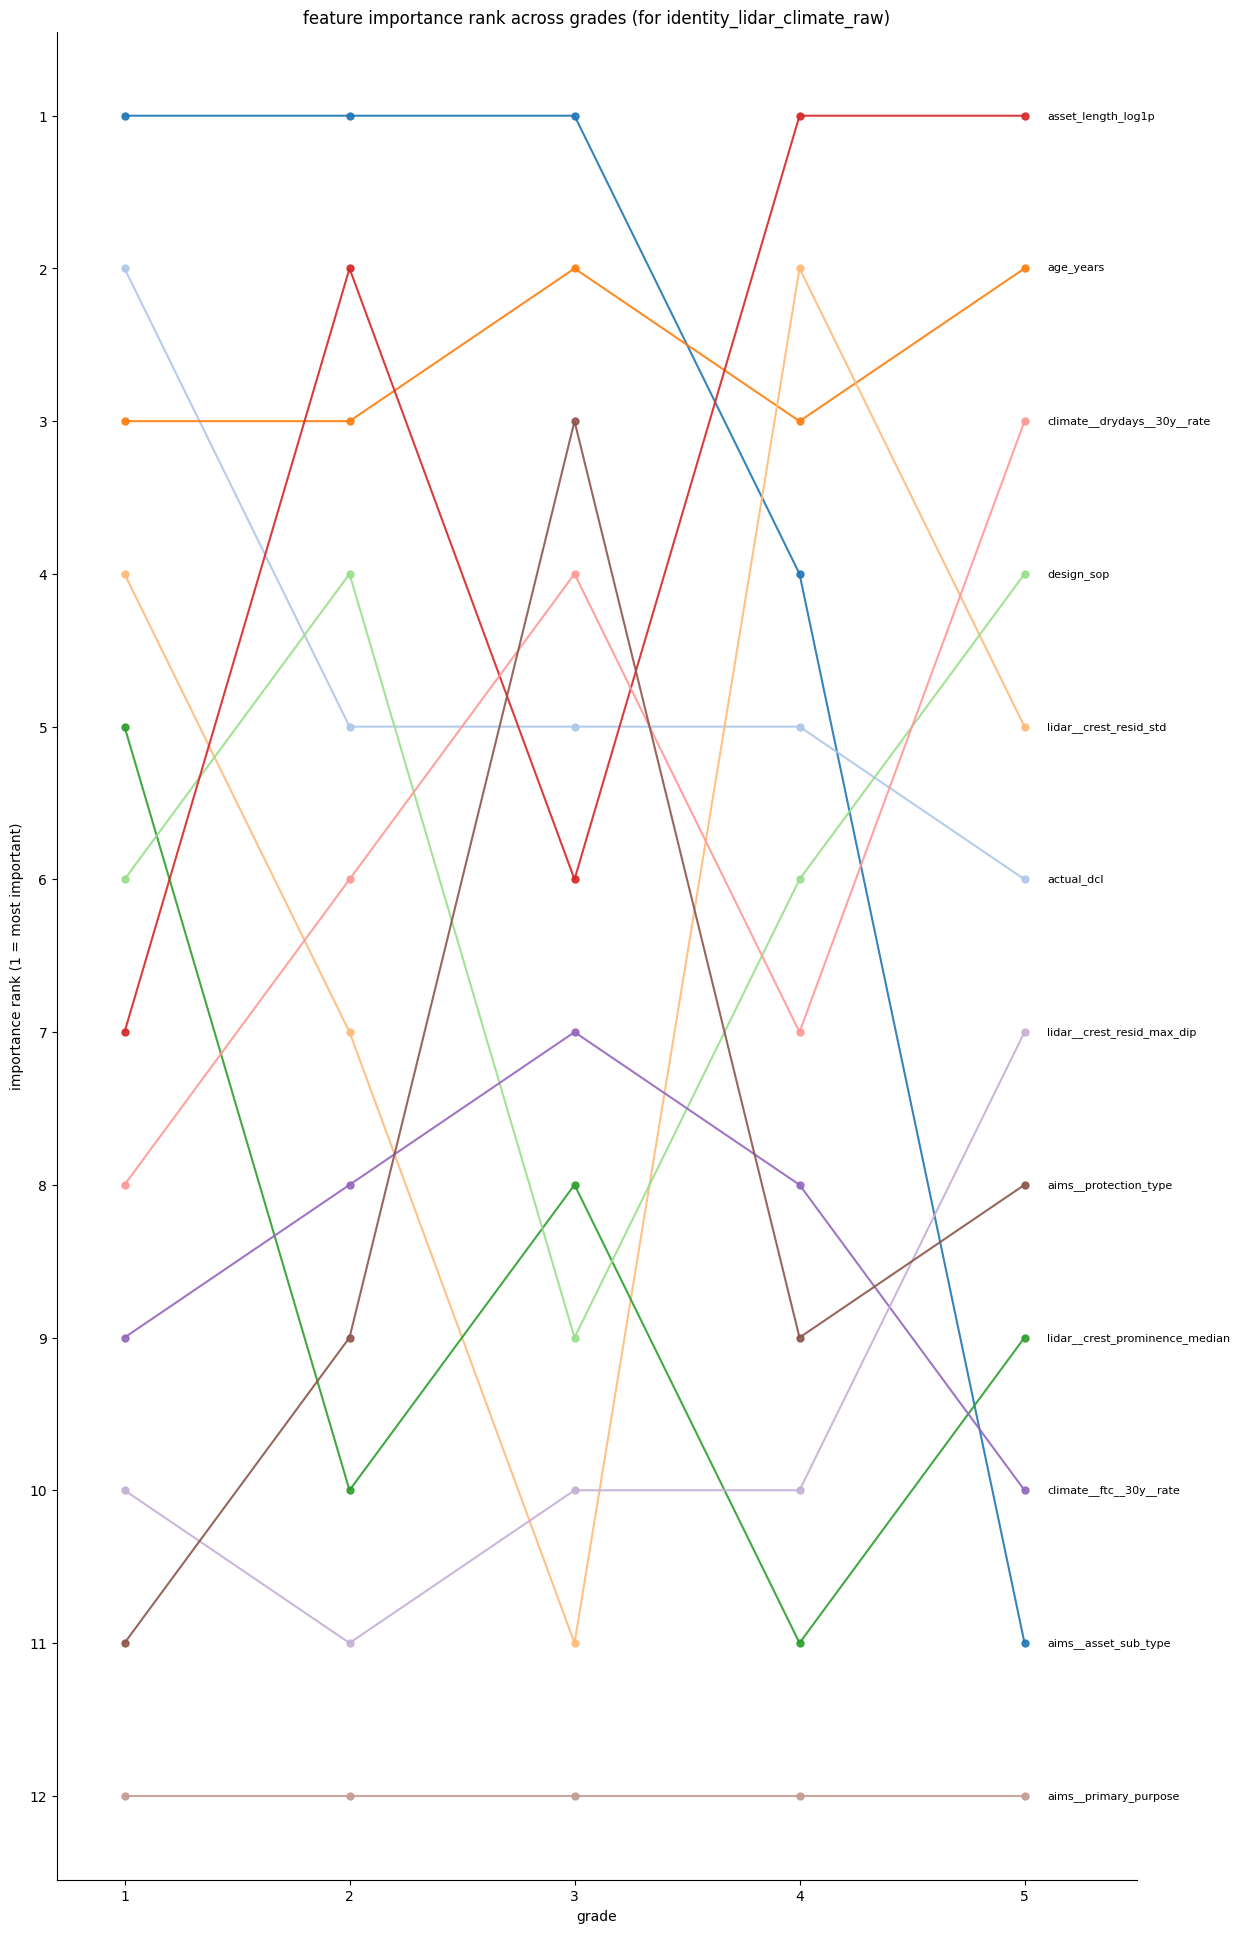

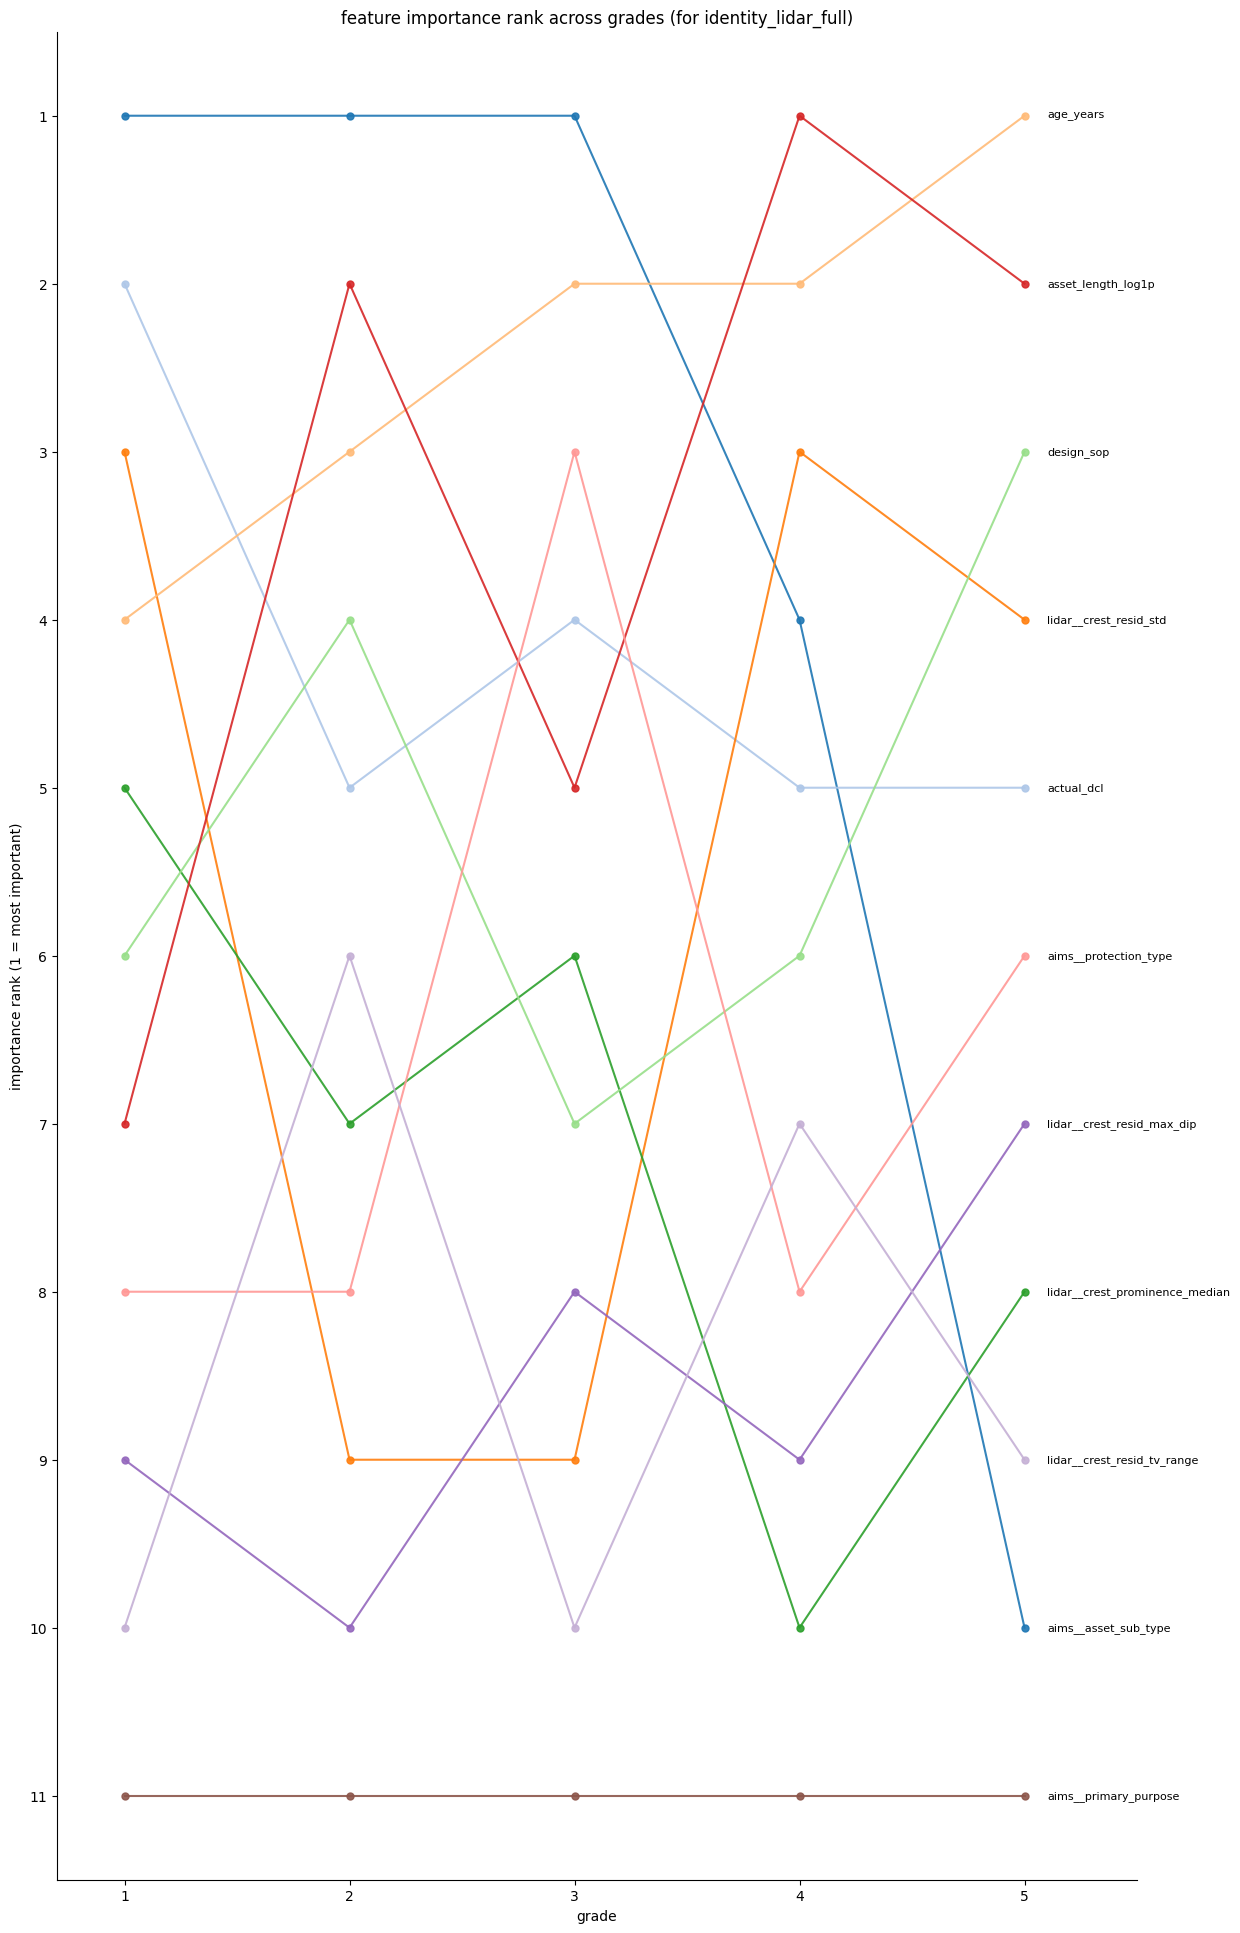

In [28]:
import matplotlib.pyplot as plt 

for feature_set in feature_importance.get_column("composition").unique().to_list():

    bump = (
        feature_importance.filter(pl.col("composition") == feature_set)
        .with_columns(pl.col("mean_abs_shap").rank(descending=True).over("grade").alias("plot_rank"))
        .sort("feature", "grade")
    )

    # print(bump)



    grades = [1, 2, 3, 4, 5]

    # start with order for grade 1 importances

    features = bump.filter(pl.col("grade") == 1).sort("plot_rank").get_column("feature").to_list()


    fig, ax = plt.subplots(figsize=(24, 24))
    fig.subplots_adjust(left=0.25, right=0.70)   # canvas room for the endpoint labels

    cmap = plt.get_cmap("tab20")
    colours = {f: cmap(i % 20) for i, f in enumerate(features)}

    for f in features:
        sub = bump.filter(pl.col("feature") == f).sort("grade")

        xs = sub.get_column("grade").to_list()
        ys = sub.get_column("plot_rank").to_list()

        ax.plot(
            xs, 
            ys, 
            "-o", 
            linewidth=1.5, 
            markersize=5, 
            alpha=0.9,
            c=colours[f]
        )

        # ax.text(
        #     xs[0] - 0.10, 
        #     ys[0], 
        #     f, 
        #     ha="right", 
        #     va="center",
        #     fontsize=8, 
        #     clip_on=False
        # )

        ax.text(
            xs[-1] + 0.10, 
            ys[-1], 
            f, 
            ha="left", 
            va="center",
            fontsize=8, 
            clip_on=False
        )


    ax.set_xticks(grades)
    ax.set_yticks(range(1, len(features) + 1))
    ax.set_xlim(0.7, 5.5)
    ax.invert_yaxis() # rank 1 highest, at the top
    ax.set_xlabel("grade")
    ax.set_ylabel("importance rank (1 = most important)")
    ax.set_title(f"feature importance rank across grades (for {feature_set})")
    ax.spines[["top", "right"]].set_visible(False)

    plt.show()

In [29]:
axes = ["capacity", "learning_rate", "max_iter", "max_leaf_nodes", "min_samples_leaf", "l2_regularization"]

axis_effect = (
    cell_summary.filter(pl.col("composition").is_not_null())
    .with_columns(pl.col(axes).cast(pl.Float64))
    .unpivot(
        index=["composition", "cell_id", "pr_auc_ge4", "qwk"],
        on=axes,
        variable_name="axis",
        value_name="level",
    )
    .group_by("axis", "level")
    .agg(
        pl.col("pr_auc_ge4").mean().alias("pr_auc"),
        pl.col("qwk").mean().alias("qwk"),
        pl.len().alias("n_cells"),
    )
    .sort("axis", "level")
)

axis_effect

axis,level,pr_auc,qwk,n_cells
str,f64,f64,f64,u32
"""capacity""",1.6,0.187961,0.277576,576
"""capacity""",2.5,0.189388,0.2847,576
"""capacity""",4.0,0.189177,0.286636,576
"""capacity""",5.0,0.18869,0.286701,576
"""capacity""",6.0,0.18839,0.286127,576
…,…,…,…,…
"""max_leaf_nodes""",16.0,0.190688,0.285197,720
"""max_leaf_nodes""",31.0,0.189311,0.282426,720
"""min_samples_leaf""",5.0,0.188836,0.284034,960


In [30]:
with pl.Config(tbl_rows=-1):
    print(axis_effect)

shape: (35, 5)
┌───────────────────┬─────────┬──────────┬──────────┬─────────┐
│ axis              ┆ level   ┆ pr_auc   ┆ qwk      ┆ n_cells │
│ ---               ┆ ---     ┆ ---      ┆ ---      ┆ ---     │
│ str               ┆ f64     ┆ f64      ┆ f64      ┆ u32     │
╞═══════════════════╪═════════╪══════════╪══════════╪═════════╡
│ capacity          ┆ 1.6     ┆ 0.187961 ┆ 0.277576 ┆ 576     │
│ capacity          ┆ 2.5     ┆ 0.189388 ┆ 0.2847   ┆ 576     │
│ capacity          ┆ 4.0     ┆ 0.189177 ┆ 0.286636 ┆ 576     │
│ capacity          ┆ 5.0     ┆ 0.18869  ┆ 0.286701 ┆ 576     │
│ capacity          ┆ 6.0     ┆ 0.18839  ┆ 0.286127 ┆ 576     │
│ l2_regularization ┆ 0.0     ┆ 0.188516 ┆ 0.284214 ┆ 1440    │
│ l2_regularization ┆ 1.0     ┆ 0.188927 ┆ 0.284482 ┆ 1440    │
│ learning_rate     ┆ 0.00625 ┆ 0.188903 ┆ 0.283823 ┆ 720     │
│ learning_rate     ┆ 0.0125  ┆ 0.188937 ┆ 0.28389  ┆ 720     │
│ learning_rate     ┆ 0.025   ┆ 0.188813 ┆ 0.28439  ┆ 720     │
│ learning_rate     ┆ 0.0

In [31]:
with pl.Config(tbl_rows=-1):
    print(
        cell_summary.filter(pl.col("composition").is_not_null())
        .group_by("max_leaf_nodes", "max_bins")
        .agg(
            pl.col("pr_auc_ge4").mean(),
            pl.col("qwk").mean(),
            pl.len().alias("n_cells"),
        )
        .sort("max_leaf_nodes", "max_bins", nulls_last=True)
    )

shape: (12, 5)
┌────────────────┬──────────┬────────────┬──────────┬─────────┐
│ max_leaf_nodes ┆ max_bins ┆ pr_auc_ge4 ┆ qwk      ┆ n_cells │
│ ---            ┆ ---      ┆ ---        ┆ ---      ┆ ---     │
│ i64            ┆ i64      ┆ f64        ┆ f64      ┆ u32     │
╞════════════════╪══════════╪════════════╪══════════╪═════════╡
│ 4              ┆ 16       ┆ 0.184947   ┆ 0.280148 ┆ 240     │
│ 4              ┆ 32       ┆ 0.18544    ┆ 0.285533 ┆ 240     │
│ 4              ┆ 255      ┆ 0.185782   ┆ 0.285241 ┆ 240     │
│ 8              ┆ 16       ┆ 0.189856   ┆ 0.282948 ┆ 240     │
│ 8              ┆ 32       ┆ 0.1899     ┆ 0.288914 ┆ 240     │
│ 8              ┆ 255      ┆ 0.188733   ┆ 0.286523 ┆ 240     │
│ 16             ┆ 16       ┆ 0.189554   ┆ 0.282753 ┆ 240     │
│ 16             ┆ 32       ┆ 0.190609   ┆ 0.286894 ┆ 240     │
│ 16             ┆ 255      ┆ 0.1919     ┆ 0.285943 ┆ 240     │
│ 31             ┆ 16       ┆ 0.188916   ┆ 0.278844 ┆ 240     │
│ 31             ┆ 32    

In [32]:
axes = ["capacity", "learning_rate", "max_iter", "max_leaf_nodes", "min_samples_leaf", "l2_regularization", "max_bins"]

axis_effect_lc = (
    cell_summary.filter(pl.col("learning_rate").eq(0.0125)).filter(pl.col("composition").is_not_null())
    .with_columns(pl.col(axes).cast(pl.Float64))
    .unpivot(
        index=["composition", "cell_id", "pr_auc_ge4", "qwk",],
        on=axes,
        variable_name="axis",
        value_name="level",
    )
    .group_by("axis", "level")
    .agg(
        pl.col("pr_auc_ge4").mean().alias("pr_auc"),
        pl.col("qwk").mean().alias("qwk"),
        pl.len().alias("n_cells"),
    )
    .sort("axis", "level")
)

with pl.Config(tbl_rows=-1):
    print(axis_effect_lc)

shape: (23, 5)
┌───────────────────┬────────┬──────────┬──────────┬─────────┐
│ axis              ┆ level  ┆ pr_auc   ┆ qwk      ┆ n_cells │
│ ---               ┆ ---    ┆ ---      ┆ ---      ┆ ---     │
│ str               ┆ f64    ┆ f64      ┆ f64      ┆ u32     │
╞═══════════════════╪════════╪══════════╪══════════╪═════════╡
│ capacity          ┆ 1.6    ┆ 0.188219 ┆ 0.276657 ┆ 144     │
│ capacity          ┆ 2.5    ┆ 0.18973  ┆ 0.284239 ┆ 144     │
│ capacity          ┆ 4.0    ┆ 0.189367 ┆ 0.286382 ┆ 144     │
│ capacity          ┆ 5.0    ┆ 0.188832 ┆ 0.286411 ┆ 144     │
│ capacity          ┆ 6.0    ┆ 0.18854  ┆ 0.28576  ┆ 144     │
│ l2_regularization ┆ 0.0    ┆ 0.188991 ┆ 0.283801 ┆ 360     │
│ l2_regularization ┆ 1.0    ┆ 0.188884 ┆ 0.283978 ┆ 360     │
│ learning_rate     ┆ 0.0125 ┆ 0.188937 ┆ 0.28389  ┆ 720     │
│ max_bins          ┆ 16.0   ┆ 0.188595 ┆ 0.280753 ┆ 240     │
│ max_bins          ┆ 32.0   ┆ 0.18871  ┆ 0.286517 ┆ 240     │
│ max_bins          ┆ 255.0  ┆ 0.189508 

In [33]:


cm_cells = (
    cell_summary.filter(
        pl.all_horizontal(
            pl.col("learning_rate").eq(0.0125), 
            pl.col("l2_regularization").eq(0.0),
            pl.col("max_bins").eq(255.),
            pl.col("max_leaf_nodes").eq(16.0),
            pl.col("max_iter").eq(200.),
            pl.col("min_samples_leaf").eq(5)
        ) | pl.col("composition").is_null())
    .select("cell_id", "model", "composition")
    .with_columns(
        pl.coalesce(pl.col("composition"), pl.col("model")).alias("label")
    )
    .sort("composition", "model")
)

cm_oof = pl.concat(
    [
        pl.read_parquet(oof_dir / f"{cell_id}.parquet").select(
            "cell_id", "y_true", "y_pred_argmax"
        )
        for cell_id in cm_cells.get_column("cell_id")
    ]
).join(cm_cells, on="cell_id", how="left", validate="m:1")

cm_oof.get_column("label").unique()

label
str
"""identity_lidar_climate_raw"""
"""dummy_median"""
"""identity_lidar_full"""
"""heuristic_national"""
"""dummy_stratified"""


In [34]:
cell_summary.filter(
        pl.all_horizontal(
            pl.col("learning_rate").eq(0.0125), 
            pl.col("l2_regularization").eq(0.0),
            pl.col("max_bins").eq(255.),
            pl.col("max_leaf_nodes").eq(16.0),
            pl.col("max_iter").eq(200.)
        ) | pl.col("composition").is_null()
).select(
    "cell_id", 
)

cell_id
str
"""ba81faf7a77c"""
"""0c7581b6dc44"""
"""4afa0082a12f"""
"""c50b10f43b02"""
"""1e2ffe2aff9f"""
"""c1177653fbec"""
"""a92580c838e7"""
"""0310867235f0"""
"""2f02fa875bc1"""


In [35]:
GRADE_FRAME = pl.DataFrame({"grade": [1, 2, 3, 4, 5]}, schema={"grade": pl.Int8})


def confusion(oof: pl.DataFrame, by_fold: bool = False) -> pl.DataFrame:
    """5x5 confusion, long form, zeros filled so all 25 cells exist per group."""
    keys = ["cell_id", "label"] + (["fold_id"] if by_fold else [])

    counted = oof.group_by([*keys, "y_true", "y_pred_argmax"]).agg(
        pl.len().cast(pl.Int32).alias("n")
    )

    grid = (
        oof.select(keys)
        .unique()
        .join(GRADE_FRAME.rename({"grade": "y_true"}), how="cross")
        .join(GRADE_FRAME.rename({"grade": "y_pred_argmax"}), how="cross")
    )

    return (
        grid.join(counted, on=[*keys, "y_true", "y_pred_argmax"], how="left")
        .with_columns(pl.col("n").fill_null(0).cast(pl.Int32))
        .sort([*keys, "y_true", "y_pred_argmax"])
    )


cm = confusion(cm_oof)

In [36]:
cm

cell_id,label,y_true,y_pred_argmax,n
str,str,i8,i8,i32
"""0c7581b6dc44""","""dummy_stratified""",1,1,5
"""0c7581b6dc44""","""dummy_stratified""",1,2,128
"""0c7581b6dc44""","""dummy_stratified""",1,3,274
"""0c7581b6dc44""","""dummy_stratified""",1,4,28
"""0c7581b6dc44""","""dummy_stratified""",1,5,12
…,…,…,…,…
"""c50b10f43b02""","""identity_lidar_climate_raw""",5,1,0
"""c50b10f43b02""","""identity_lidar_climate_raw""",5,2,13
"""c50b10f43b02""","""identity_lidar_climate_raw""",5,3,246


In [37]:
cm.group_by("label").len()

label,len
str,u32
"""identity_lidar_climate_raw""",25
"""dummy_median""",25
"""identity_lidar_full""",25
"""heuristic_national""",25
"""dummy_stratified""",25


In [38]:
import seaborn as sns

ALL_GRADES = [1, 2, 3, 4, 5]


def plot_confusion_matrix(cm_wide: pl.DataFrame, title: str, ax):
    for grade in ALL_GRADES:
        if str(grade) not in cm_wide.columns:
            cm_wide = cm_wide.with_columns(pl.lit(0).cast(pl.Int32).alias(str(grade)))

    pred_cols = [str(g) for g in ALL_GRADES]
    counts = cm_wide.select(pred_cols).to_numpy().astype(float)

    row_sums = counts.sum(axis=1, keepdims=True)
    display = np.divide(counts, row_sums, out=np.zeros_like(counts), where=row_sums != 0)

    sns.heatmap(
        display,
        cmap="viridis",
        vmin=0,
        vmax=1,
        cbar=False,
        xticklabels=pred_cols,
        yticklabels=cm_wide["y_true"].to_list(),
        ax=ax,
        linewidths=0.5,
        linecolor="black",
    )

    for i in range(counts.shape[0]):
        for j in range(counts.shape[1]):
            ax.text(
                j + 0.5,
                i + 0.5,
                f"{display[i, j]:.0%}\n({int(counts[i, j])})",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if display[i, j] < 0.6 else "black",
            )

    ax.set_xlabel("Predicted grade")
    ax.set_ylabel("True grade")
    ax.set_title(title, fontsize=10)
    return ax

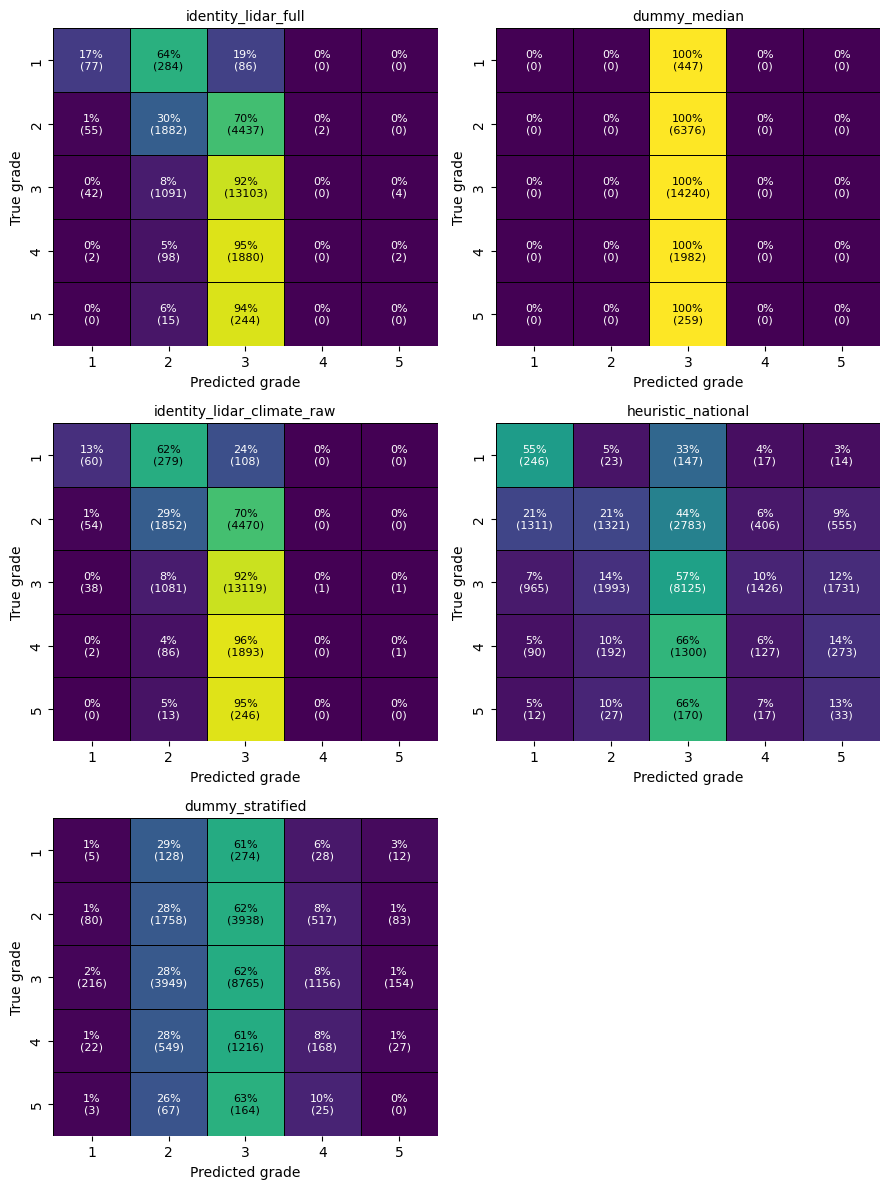

In [39]:
labels = cm_cells.get_column("label").unique().to_list()
ncols = 2
nrows = -(-len(labels) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(9, 4 * nrows))
axes = axes.flatten()

for ax, label in zip(axes, labels):
    cm_wide = (
        cm.filter(pl.col("label") == label)
        .select("y_true", "y_pred_argmax", "n")
        .pivot(on="y_pred_argmax", index="y_true", values="n")
        .sort("y_true")
    )
    plot_confusion_matrix(cm_wide, title=label, ax=ax)

for ax in axes[len(labels):]:
    ax.axis("off")

fig.tight_layout()
plt.show()

In [40]:
sweep_cells = pl.concat(
    [
        cell_summary.filter(pl.col("composition") == feature_set)
        .sort("pr_auc_ge4", descending=True)
        .head(1)
        .select("cell_id", "model", "composition", "pr_auc_ge4", "qwk")
        for feature_set in ["identity_lidar_climate_raw", "identity_lidar_full"]
    ]
    + [
        cell_summary.filter(pl.col("composition").is_null()).select(
            "cell_id", "model", "composition", "pr_auc_ge4", "qwk"
        )
    ]
).with_columns(pl.coalesce(pl.col("composition"), pl.col("model")).alias("label"))

sweep_oof = pl.concat(
    [
        pl.read_parquet(oof_dir / f"{cell_id}.parquet").select(
            "cell_id",
            "fold_id",
            "asset_id",
            "y_true",
            pl.sum_horizontal("proba_4", "proba_5").alias("score"),
        )
        for cell_id in sweep_cells.get_column("cell_id")
    ]
).join(sweep_cells, on="cell_id", how="left", validate="m:1").with_columns(
    (pl.col("y_true") >= 4).alias("is_positive")
)

sweep_cells

cell_id,model,composition,pr_auc_ge4,qwk,label
str,str,str,f64,f64,str
"""8de98379fe6f""","""hgb""","""identity_lidar_climate_raw""",0.197655,0.280176,"""identity_lidar_climate_raw"""
"""57eee29de136""","""hgb""","""identity_lidar_full""",0.19595,0.284508,"""identity_lidar_full"""
"""ba81faf7a77c""","""heuristic_national""",null,0.098838,0.185143,"""heuristic_national"""
"""0c7581b6dc44""","""dummy_stratified""",null,0.097513,-0.000851,"""dummy_stratified"""
"""4afa0082a12f""","""dummy_median""",null,0.096583,0.0,"""dummy_median"""


In [41]:
sweep_curve = (
    sweep_oof.group_by("cell_id", "label", "score")
    .agg(
        pl.len().alias("n_at_score"),
        pl.col("is_positive").sum().alias("n_pos_at_score"),
    )
    .sort("cell_id", "score", descending=[False, True])
    .with_columns(
        pl.col("n_at_score").cum_sum().over("cell_id").alias("n_flagged"),
        pl.col("n_pos_at_score").cum_sum().over("cell_id").alias("n_true_positive"),
        pl.col("n_at_score").sum().over("cell_id").alias("n_total"),
        pl.col("n_pos_at_score").sum().over("cell_id").alias("n_positive_total"),
    )
    .with_columns(
        (pl.col("n_true_positive") / pl.col("n_flagged")).alias("precision"),
        (pl.col("n_true_positive") / pl.col("n_positive_total")).alias("recall"),
        (pl.col("n_flagged") / pl.col("n_total")).alias("flagged_pct"),
        (pl.col("n_positive_total") / pl.col("n_total")).alias("base_rate"),
    )
    .with_columns((pl.col("precision") / pl.col("base_rate")).alias("lift"))
    .select(
        "label", "score", "n_flagged", "flagged_pct", "n_true_positive", "precision", "recall", "lift", "base_rate",
    )
)

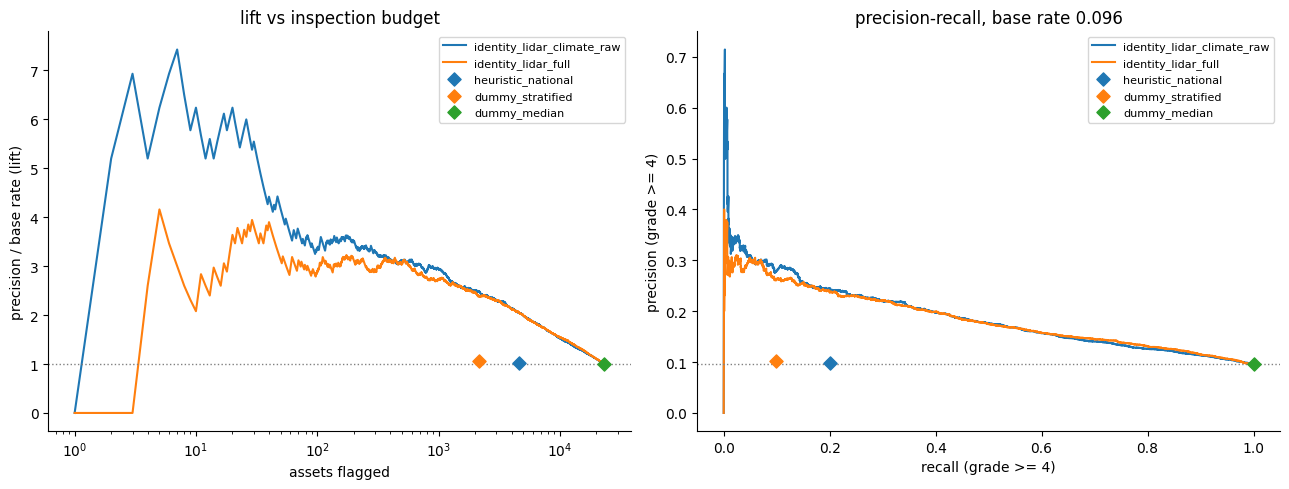

In [42]:
model_labels = ["identity_lidar_climate_raw", "identity_lidar_full"]
point_labels = ["heuristic_national", "dummy_stratified", "dummy_median"]
base_rate = sweep_curve.get_column("base_rate").max()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label in model_labels:
    curve = sweep_curve.filter(pl.col("label") == label).sort("n_flagged")
    axes[0].plot(curve["n_flagged"], curve["lift"], label=label, linewidth=1.5)
    axes[1].plot(curve["recall"], curve["precision"], label=label, linewidth=1.5)

for label in point_labels:
    point = (
        sweep_curve.filter((pl.col("label") == label) & (pl.col("n_flagged") > 0))
        .sort("lift", descending=True)
        .head(1)
    )
    axes[0].scatter(point["n_flagged"], point["lift"], marker="D", s=45, zorder=5, label=label)
    axes[1].scatter(point["recall"], point["precision"], marker="D", s=45, zorder=5, label=label)

axes[0].axhline(1.0, color="grey", linestyle=":", linewidth=1)
axes[0].set_xscale("log")
axes[0].set_xlabel("assets flagged")
axes[0].set_ylabel("precision / base rate (lift)")
axes[0].set_title("lift vs inspection budget")

axes[1].axhline(base_rate, color="grey", linestyle=":", linewidth=1)
axes[1].set_xlabel("recall (grade >= 4)")
axes[1].set_ylabel("precision (grade >= 4)")
axes[1].set_title(f"precision-recall, base rate {base_rate:.3f}")

for ax in axes:
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

In [43]:
budget = 200
matrix_labels = ["identity_lidar_climate_raw", "identity_lidar_full", "heuristic_national"]

binary_rows = []
for label in matrix_labels:
    ranked = sweep_oof.filter(pl.col("label") == label).sort("score", descending=True)
    flagged = (
        ranked.with_row_index("rank")
        .with_columns((pl.col("rank") < budget).alias("flagged"))
        .group_by("flagged", "is_positive")
        .agg(pl.len().alias("n"))
    )
    binary_rows.append(flagged.with_columns(pl.lit(label).alias("label")))

binary_matrix = (
    pl.concat(binary_rows)
    .pivot(on="is_positive", index=["label", "flagged"], values="n")
    .rename({"true": "actually_ge4", "false": "actually_below4"})
    .sort("label", "flagged", descending=[False, True])
)

binary_matrix

label,flagged,actually_ge4,actually_below4
str,bool,u32,u32
"""heuristic_national""",true,24,176
"""heuristic_national""",false,2217,20887
"""identity_lidar_climate_raw""",true,67,133
"""identity_lidar_climate_raw""",false,2174,20930
"""identity_lidar_full""",true,60,140
"""identity_lidar_full""",false,2181,20923


In [44]:
binary_summary = (
    binary_matrix.group_by("label")
    .agg(
        pl.col("actually_ge4").filter(pl.col("flagged")).first().alias("true_positive"),
        pl.col("actually_below4").filter(pl.col("flagged")).first().alias("false_positive"),
        pl.col("actually_ge4").filter(~pl.col("flagged")).first().alias("false_negative"),
        pl.col("actually_below4").filter(~pl.col("flagged")).first().alias("true_negative"),
    )
    .with_columns(
        (pl.col("true_positive") / (pl.col("true_positive") + pl.col("false_positive"))).alias("precision"),
        (pl.col("true_positive") / (pl.col("true_positive") + pl.col("false_negative"))).alias("recall"),
    )
    .with_columns((pl.col("precision") / 0.096164).alias("lift"))
    .sort("lift", descending=True)
)

binary_summary

label,true_positive,false_positive,false_negative,true_negative,precision,recall,lift
str,u32,u32,u32,u32,f64,f64,f64
"""identity_lidar_climate_raw""",67,133,2174,20930,0.335,0.029897,3.483632
"""identity_lidar_full""",60,140,2181,20923,0.3,0.026774,3.119671
"""heuristic_national""",24,176,2217,20887,0.12,0.01071,1.247868


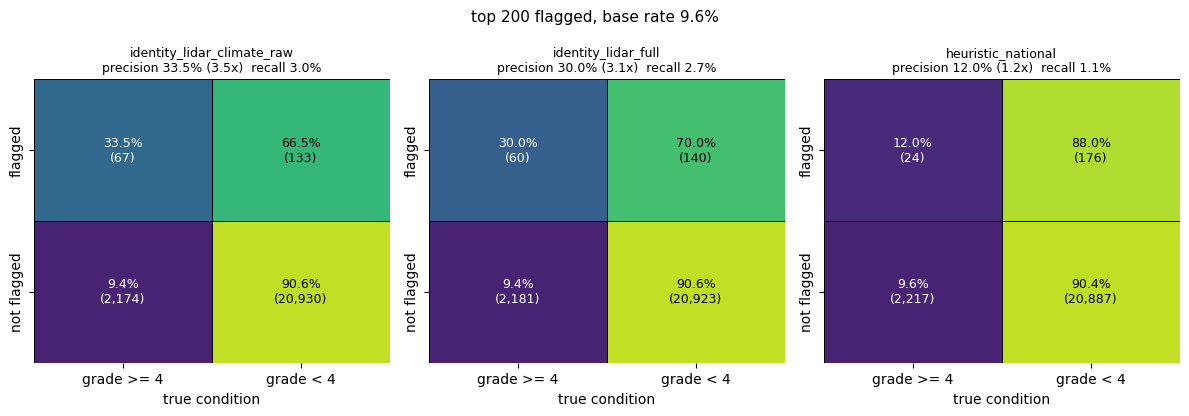

In [45]:
base_rate = 0.096164

fig, axes = plt.subplots(1, len(matrix_labels), figsize=(4 * len(matrix_labels), 4.2))

for ax, label in zip(axes, matrix_labels):
    ranked = sweep_oof.filter(pl.col("label") == label).sort("score", descending=True)
    positives = ranked.get_column("is_positive").to_numpy()

    true_positive = int(positives[:budget].sum())
    false_positive = budget - true_positive
    false_negative = int(positives[budget:].sum())
    true_negative = len(positives) - budget - false_negative

    counts = np.array([[true_positive, false_positive], [false_negative, true_negative]])
    shares = counts / counts.sum(axis=1, keepdims=True)

    sns.heatmap(
        shares,
        cmap="viridis",
        vmin=0,
        vmax=1,
        cbar=False,
        xticklabels=["grade >= 4", "grade < 4"],
        yticklabels=["flagged", "not flagged"],
        ax=ax,
        linewidths=0.5,
        linecolor="black",
    )

    for i in range(2):
        for j in range(2):
            ax.text(
                j + 0.5,
                i + 0.5,
                f"{shares[i, j]:.1%}\n({counts[i, j]:,})",
                ha="center",
                va="center",
                fontsize=9,
                color="white" if shares[i, j] < 0.6 else "black",
            )

    precision = true_positive / budget
    recall = true_positive / (true_positive + false_negative)
    ax.set_title(
        f"{label}\nprecision {precision:.1%} ({precision / base_rate:.1f}x)  recall {recall:.1%}",
        fontsize=9,
    )
    ax.set_xlabel("true condition")
    ax.set_ylabel("")

fig.suptitle(f"top {budget} flagged, base rate {base_rate:.1%}", fontsize=11)
fig.tight_layout()
plt.show()

In [46]:
from experiments.final_grid.models import GRID_AXES

GRID_AXES



('capacity',
 'learning_rate',
 'max_leaf_nodes',
 'min_samples_leaf',
 'max_bins',
 'l2_regularization')

In [47]:
# sweep_cells already holds one cell per arm - reading the cell_id off sweep_oof instead sorts 23,304
# asset rows by their predicted score and returns whichever cell owned the single most confident
# asset, which is only the right answer while there is exactly one cell per label.

top_config_cell_id = (
    sweep_cells.filter(pl.col("label").eq("identity_lidar_climate_raw"))
    .get_column("cell_id")
    .item()
)

top_config_cell = cell_summary.filter(pl.col("cell_id").eq(top_config_cell_id))

top_config_cell


cell_id,f1_for_grade_1,f1_for_grade_2,f1_for_grade_3,f1_for_grade_4,f1_for_grade_5,macro_f1,mae,pr_auc_ge4,precision_for_grade_1,precision_for_grade_2,precision_for_grade_3,precision_for_grade_4,precision_for_grade_5,qwk,recall_for_grade_1,recall_for_grade_2,recall_for_grade_3,recall_for_grade_4,recall_for_grade_5,model,composition,capacity,seconds_fit,seconds_shap,seconds_total,learning_rate,max_iter,max_leaf_nodes,max_depth,max_bins,l2_regularization,min_samples_leaf,config_key
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,i64,i64,null,i64,f64,i64,str
"""8de98379fe6f""",0.118617,0.383832,0.76868,0.00099,0.0,0.254424,0.377966,0.197655,0.261515,0.559102,0.660649,0.1,0.0,0.280176,0.087056,0.295257,0.921041,0.000498,0.0,"""hgb""","""identity_lidar_climate_raw""",1.6,22.54,0.0,24.584,0.025,64,31,null,255,0.0,5,"""0.025|64|31|none|255|0.0|5"""


In [48]:


top_config = top_config_cell.select(GRID_AXES).row(named=True)

top_config


{'capacity': 1.6,
 'learning_rate': 0.025,
 'max_leaf_nodes': 31,
 'min_samples_leaf': 5,
 'max_bins': 255,
 'l2_regularization': 0.0}

In [49]:
alt_top_config_cell_id = (
    cell_summary.filter(pl.col("composition").eq("identity_lidar_climate_raw"))
    .sort(by="qwk", descending=True)
    .head(1)
    .get_column("cell_id")
    .item()
)

alt_top_config_cell = cell_summary.filter(pl.col("cell_id").eq(alt_top_config_cell_id))

alt_top_config_cell


cell_id,f1_for_grade_1,f1_for_grade_2,f1_for_grade_3,f1_for_grade_4,f1_for_grade_5,macro_f1,mae,pr_auc_ge4,precision_for_grade_1,precision_for_grade_2,precision_for_grade_3,precision_for_grade_4,precision_for_grade_5,qwk,recall_for_grade_1,recall_for_grade_2,recall_for_grade_3,recall_for_grade_4,recall_for_grade_5,model,composition,capacity,seconds_fit,seconds_shap,seconds_total,learning_rate,max_iter,max_leaf_nodes,max_depth,max_bins,l2_regularization,min_samples_leaf,config_key
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,i64,i64,null,i64,f64,i64,str
"""c3a7619f319d""",0.208604,0.388975,0.769353,0.0,0.0,0.273386,0.375086,0.183716,0.387,0.567812,0.661763,0.0,0.0,0.293851,0.152114,0.299335,0.92072,0.0,0.0,"""hgb""","""identity_lidar_climate_raw""",5.0,19.698,0.0,22.765,0.05,100,4,null,255,1.0,20,"""0.05|100|4|none|255|1.0|20"""


In [50]:

alt_top_config = alt_top_config_cell.select(GRID_AXES).row(named=True)

alt_top_config

{'capacity': 5.0,
 'learning_rate': 0.05,
 'max_leaf_nodes': 4,
 'min_samples_leaf': 20,
 'max_bins': 255,
 'l2_regularization': 1.0}

In [51]:
top_config_three_id = (
    cell_summary.filter(pl.col("composition").eq("identity_lidar_climate_raw"))
    .sort(by="pr_auc_ge4", descending=True)
    .head(1)
    .get_column("cell_id")
    .item()
)

top_config_three_cell = cell_summary.filter(pl.col("cell_id").eq(top_config_three_id))

top_config_three_cell

cell_id,f1_for_grade_1,f1_for_grade_2,f1_for_grade_3,f1_for_grade_4,f1_for_grade_5,macro_f1,mae,pr_auc_ge4,precision_for_grade_1,precision_for_grade_2,precision_for_grade_3,precision_for_grade_4,precision_for_grade_5,qwk,recall_for_grade_1,recall_for_grade_2,recall_for_grade_3,recall_for_grade_4,recall_for_grade_5,model,composition,capacity,seconds_fit,seconds_shap,seconds_total,learning_rate,max_iter,max_leaf_nodes,max_depth,max_bins,l2_regularization,min_samples_leaf,config_key
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,i64,i64,null,i64,f64,i64,str
"""8de98379fe6f""",0.118617,0.383832,0.76868,0.00099,0.0,0.254424,0.377966,0.197655,0.261515,0.559102,0.660649,0.1,0.0,0.280176,0.087056,0.295257,0.921041,0.000498,0.0,"""hgb""","""identity_lidar_climate_raw""",1.6,22.54,0.0,24.584,0.025,64,31,null,255,0.0,5,"""0.025|64|31|none|255|0.0|5"""


In [52]:

top_config_three = top_config_three_cell.select(GRID_AXES).row(named=True)

top_config_three

{'capacity': 1.6,
 'learning_rate': 0.025,
 'max_leaf_nodes': 31,
 'min_samples_leaf': 5,
 'max_bins': 255,
 'l2_regularization': 0.0}

In [53]:
top_config_four_id = (
    cell_summary
    .sort(by="pr_auc_ge4", descending=True)
    .head(1)
    .get_column("cell_id")
    .item()
)

top_config_four_cell = cell_summary.filter(pl.col("cell_id").eq(top_config_four_id))

top_config_four_cell

cell_id,f1_for_grade_1,f1_for_grade_2,f1_for_grade_3,f1_for_grade_4,f1_for_grade_5,macro_f1,mae,pr_auc_ge4,precision_for_grade_1,precision_for_grade_2,precision_for_grade_3,precision_for_grade_4,precision_for_grade_5,qwk,recall_for_grade_1,recall_for_grade_2,recall_for_grade_3,recall_for_grade_4,recall_for_grade_5,model,composition,capacity,seconds_fit,seconds_shap,seconds_total,learning_rate,max_iter,max_leaf_nodes,max_depth,max_bins,l2_regularization,min_samples_leaf,config_key
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,i64,i64,null,i64,f64,i64,str
"""8de98379fe6f""",0.118617,0.383832,0.76868,0.00099,0.0,0.254424,0.377966,0.197655,0.261515,0.559102,0.660649,0.1,0.0,0.280176,0.087056,0.295257,0.921041,0.000498,0.0,"""hgb""","""identity_lidar_climate_raw""",1.6,22.54,0.0,24.584,0.025,64,31,null,255,0.0,5,"""0.025|64|31|none|255|0.0|5"""


In [54]:
top_config_four = top_config_four_cell.select([*GRID_AXES, "composition"]).row(named=True)

top_config_four

{'capacity': 1.6,
 'learning_rate': 0.025,
 'max_leaf_nodes': 31,
 'min_samples_leaf': 5,
 'max_bins': 255,
 'l2_regularization': 0.0,
 'composition': 'identity_lidar_climate_raw'}

In [55]:
top_config_five_id = (
    cell_summary
    .sort(by="qwk", descending=True)
    .head(1)
    .get_column("cell_id")
    .item()
)

top_config_five_cell = cell_summary.filter(pl.col("cell_id").eq(top_config_five_id))

top_config_five_cell

cell_id,f1_for_grade_1,f1_for_grade_2,f1_for_grade_3,f1_for_grade_4,f1_for_grade_5,macro_f1,mae,pr_auc_ge4,precision_for_grade_1,precision_for_grade_2,precision_for_grade_3,precision_for_grade_4,precision_for_grade_5,qwk,recall_for_grade_1,recall_for_grade_2,recall_for_grade_3,recall_for_grade_4,recall_for_grade_5,model,composition,capacity,seconds_fit,seconds_shap,seconds_total,learning_rate,max_iter,max_leaf_nodes,max_depth,max_bins,l2_regularization,min_samples_leaf,config_key
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,i64,i64,null,i64,f64,i64,str
"""4009966c6869""",0.243114,0.390813,0.76906,0.0,0.0,0.280598,0.37543,0.19232,0.324765,0.565319,0.662962,0.0,0.0,0.300623,0.201416,0.30405,0.917776,0.0,0.0,"""hgb""","""identity_lidar_full""",4.0,12.822,0.0,14.69,0.05,80,8,null,255,1.0,5,"""0.05|80|8|none|255|1.0|5"""


In [56]:
top_config_five = top_config_five_cell.select([*GRID_AXES, "composition"]).row(named=True)

top_config_five

{'capacity': 4.0,
 'learning_rate': 0.05,
 'max_leaf_nodes': 8,
 'min_samples_leaf': 5,
 'max_bins': 255,
 'l2_regularization': 1.0,
 'composition': 'identity_lidar_full'}

In [57]:
# two different things are called GRID_AXES in this notebook, cell 5's sklearn param list (inc max_iter and max_depth) 
# and models.GRID_AXES, the six axes a config dict is built from.

from experiments.final_grid.models import GRID_AXES as GRID_AXES_CONFIG

GRID_AXES_CONFIG


('capacity',
 'learning_rate',
 'max_leaf_nodes',
 'min_samples_leaf',
 'max_bins',
 'l2_regularization')

every cell is scored on the same folds, so the fold main effect is a nuisance that differences out. the standard dev of pr_auc_ge4 across folds is ~0.016 - as wide as the entire spread across all 2,880 cells - and ranking on it puts 97% of them within one standard error of the best. Centring each fold on its own mean across cells lets me calculate the actual advantage each cell gives over the other cells 

In [58]:

fold_centred = (
    fold_metrics.filter(pl.col("model").eq("hgb"))
    .with_columns(
        (pl.col("pr_auc_ge4") - pl.col("pr_auc_ge4").mean().over("fold_id")).alias("d_pr"),
        (pl.col("qwk") - pl.col("qwk").mean().over("fold_id")).alias("d_qwk"),
    )
    .group_by("cell_id")
    .agg(
        pl.col("d_pr").mean().alias("adv"),
        (pl.col("d_pr").std() / pl.len().sqrt()).alias("se"),
        pl.col("d_qwk").mean().alias("adv_qwk"),
        pl.col("pr_auc_ge4").mean(),
        pl.col("qwk").mean(),
    )
    .join(cell_meta, on="cell_id", how="left", validate="1:1")
    .sort("adv", descending=True)
)

best = fold_centred.row(0, named=True)
band = fold_centred.filter(pl.col("adv").ge(best["adv"] - best["se"]))

print(f"best advantage {best['adv']:.6f}, paired se {best['se']:.6f}, t {best['adv'] / best['se']:.1f}")
print(f"{band.height} of {fold_centred.height} cells within one paired se of it")

fold_centred.head(10).select("composition", *GRID_AXES_CONFIG, "adv", "se", "pr_auc_ge4", "qwk")


best advantage 0.008933, paired se 0.003753, t 2.4
126 of 2880 cells within one paired se of it


composition,capacity,learning_rate,max_leaf_nodes,min_samples_leaf,max_bins,l2_regularization,adv,se,pr_auc_ge4,qwk
str,f64,f64,i64,i64,i64,f64,f64,f64,f64,f64
"""identity_lidar_climate_raw""",1.6,0.025,31,5,255,0.0,0.008933,0.003753,0.197655,0.280176
"""identity_lidar_climate_raw""",2.5,0.00625,31,5,255,0.0,0.008393,0.003373,0.197114,0.282732
"""identity_lidar_climate_raw""",2.5,0.025,31,5,255,0.0,0.008206,0.003465,0.196927,0.280443
"""identity_lidar_climate_raw""",1.6,0.0125,31,5,255,0.0,0.008104,0.003086,0.196825,0.272635
"""identity_lidar_climate_raw""",2.5,0.00625,16,5,255,0.0,0.007897,0.001777,0.196618,0.280314
"""identity_lidar_climate_raw""",2.5,0.0125,16,5,255,0.0,0.007889,0.001907,0.19661,0.279593
"""identity_lidar_climate_raw""",1.6,0.00625,31,5,255,0.0,0.00781,0.00316,0.196532,0.279792
"""identity_lidar_climate_raw""",6.0,0.0125,16,20,255,0.0,0.007797,0.001804,0.196518,0.274408
"""identity_lidar_climate_raw""",2.5,0.0125,31,5,255,0.0,0.007506,0.003577,0.196227,0.275733


In [59]:
# the band is 126 cells wide, so read its marginal structure rather than its argmax. 
# the argmax sits at 31 leaves / min_samples_leaf 5 / 255 bins 
# three axis boundaries at once

for axis in ["composition", *GRID_AXES_CONFIG]:
    counts = fold_centred.head(100).get_column(axis).value_counts().sort("count", descending=True)
    print(f"{axis:20s} {counts.to_dicts()}")


composition          [{'composition': 'identity_lidar_climate_raw', 'count': 82}, {'composition': 'identity_lidar_full', 'count': 18}]
capacity             [{'capacity': 2.5, 'count': 30}, {'capacity': 6.0, 'count': 20}, {'capacity': 1.6, 'count': 18}, {'capacity': 5.0, 'count': 17}, {'capacity': 4.0, 'count': 15}]
learning_rate        [{'learning_rate': 0.025, 'count': 31}, {'learning_rate': 0.05, 'count': 23}, {'learning_rate': 0.00625, 'count': 23}, {'learning_rate': 0.0125, 'count': 23}]
max_leaf_nodes       [{'max_leaf_nodes': 16, 'count': 67}, {'max_leaf_nodes': 31, 'count': 31}, {'max_leaf_nodes': 8, 'count': 2}]
min_samples_leaf     [{'min_samples_leaf': 5, 'count': 42}, {'min_samples_leaf': 10, 'count': 30}, {'min_samples_leaf': 20, 'count': 28}]
max_bins             [{'max_bins': 255, 'count': 81}, {'max_bins': 32, 'count': 10}, {'max_bins': 16, 'count': 9}]
l2_regularization    [{'l2_regularization': 0.0, 'count': 63}, {'l2_regularization': 1.0, 'count': 37}]


In [60]:
# what goes into final_shap and frank_hall.py
# selected on pr_auc_ge4, 
# configs maximising it land around rank 1,000 of 1,440 on qwk in both arms, so the choice of metric is making a big difference here.

selected_config = {
    "capacity": 2.5,
    "learning_rate": 0.0125,
    "max_leaf_nodes": 16,
    "min_samples_leaf": 5,
    "max_bins": 255,
    "l2_regularization": 0.0,
}

qwk_config = fold_centred.sort("adv_qwk", descending=True).head(1).select(GRID_AXES_CONFIG).to_dicts()[0]

ranked = fold_centred.with_columns(
    pl.col("adv").rank(descending=True).over("composition").alias("rank_pr"),
    pl.col("adv_qwk").rank(descending=True).over("composition").alias("rank_qwk"),
)

print(
    ranked.filter(pl.all_horizontal([pl.col(k).eq(v) for k, v in selected_config.items()])).select(
        "composition", "rank_pr", "rank_qwk", "pr_auc_ge4", "qwk"
    )
)
print(f"qwk-strongest: {qwk_config}")


shape: (2, 5)
┌────────────────────────────┬─────────┬──────────┬────────────┬──────────┐
│ composition                ┆ rank_pr ┆ rank_qwk ┆ pr_auc_ge4 ┆ qwk      │
│ ---                        ┆ ---     ┆ ---      ┆ ---        ┆ ---      │
│ str                        ┆ f64     ┆ f64      ┆ f64        ┆ f64      │
╞════════════════════════════╪═════════╪══════════╪════════════╪══════════╡
│ identity_lidar_climate_raw ┆ 6.0     ┆ 1008.0   ┆ 0.19661    ┆ 0.279593 │
│ identity_lidar_full        ┆ 3.0     ┆ 713.0    ┆ 0.195351   ┆ 0.28829  │
└────────────────────────────┴─────────┴──────────┴────────────┴──────────┘
qwk-strongest: {'capacity': 4.0, 'learning_rate': 0.05, 'max_leaf_nodes': 8, 'min_samples_leaf': 5, 'max_bins': 255, 'l2_regularization': 1.0}


In [63]:
output_dir = paths.report_data

sweep_curve.write_parquet(output_dir / "nb_21_sweep_curve.parquet")
sweep_cells.write_parquet(output_dir / "nb_21_sweep_cells.parquet")
binary_summary.write_parquet(output_dir / "nb_21_budget_confusion.parquet")
cm.write_parquet(output_dir / "nb_21_grade_confusion.parquet")
feature_importance.write_parquet(output_dir / "nb_21_shap_importance.parquet")